# Validation of NEDAS using the Lorenz 1996 model case

The Lorenz 1996 model is a one-dimensional model with $N_x = 40$ variables defined on a cyclic domain. It represents a mid-latitude zonal circle of global atmosphere with governing equations:

$$ \frac{\mathrm{d} x_n}{\mathrm{d} t} = (x_{n+1} - x_{n-2})x_{n-1} - x_n + F, $$

for $n = 1, \ldots, N_x$. The forcing $F = 8$ displays chaotic behavior. While the model is non-dimensional, it is analogous to atmospheric systems with time units $\Delta t = 0.05$ representing a $\sim 6$ hour period.

Thanks to its simplicity, the Lorenz-96 model is often used in DA for prototyping and benchmarking new methods. In this notebook, we will use this model to reproduce results in section 5.5 of [Boquet's lecture notes](https://cerea.enpc.fr/HomePages/bocquet/teaching/assim-mb-en-0.52.pdf), which serves as a validation of implementation correctness for the deterministic EnKF algorithms in NEDAS.

## System setup (optional)

In [ ]:
%pip install NEDAS

## Load the NEDAS system and dependencies

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, Image, display

from NEDAS.config import Config
from NEDAS import get_scheme

## Initialization

The config object holds all parameters defined in a yaml file, we can also make some changes

In [2]:
config = Config(config_file="lorenz96/config.yml", quiet=True)

In [3]:
config.nens = 20

In [4]:
from datetime import datetime, timedelta
ncycle = 2000
config.time_end = config.time_start + ncycle * timedelta(hours=config.cycle_period)
config.time_analysis_end = config.time_end

In [3]:
obs_rec_id = 0

In [6]:
config.obs_def[obs_rec_id]['err']['std'] = 1

In [7]:
config.obs_def[obs_rec_id]['hroi'] = np.inf

In [8]:
obs_x = [i for i in range(0, 40, 1)]
config.dataset_def['synthetic']['obs_x'] = obs_x
config.obs_def[obs_rec_id]['nobs'] = len(obs_x)

## Run the main scheme

The main scheme is the top level manager of runtime execution, it can be initialized with the config object.

Notes: 

- The first cycle takes a bit longer since the python functions are being compiled by numba.njit
- NEDAS always use real datetime to handle time controls. Lorenz96 is nondimensional, so we used the convention of $\Delta t = 0.05$ corresponding to 6 hours.

In [4]:
scheme = get_scheme(config)

In [5]:
%rm -rf lorenz96/work

In [6]:
scheme()

## Collect data from memory

In [7]:
def get_truth(scheme):
    model = scheme.c.models['lorenz96']
    scheme.c.time = scheme.c.config.time_start
    
    truth_state = []
    while scheme.c.time < scheme.c.config.time_end:
        truth_state.append(model.read_var_from_memory(tag='truth', name='state', member=None, time=scheme.c.time))
        scheme.c.time = scheme.c.next_time

    return np.array(truth_state)

def get_model_state(scheme, tag):
    model = scheme.c.models['lorenz96']
    scheme.c.time = scheme.c.config.time_start

    ens_state = []
    while scheme.c.time < scheme.c.config.time_end:
        ens = []
        for m in range(scheme.c.nens):
            try:
                state = model.read_var_from_memory(tag=tag, name='state', member=m, time=scheme.c.time)
            except Exception:
                state = model.read_var_from_memory(tag='current', name='state', member=m, time=scheme.c.time)
            ens.append(state)
        ens_state.append(ens)
        scheme.c.time = scheme.c.next_time
    return np.array(ens_state)

def get_obs(scheme):
    dataset = scheme.c.datasets['synthetic']
    nobs = scheme.c.obs.info.records[0].nobs
    scheme.c.time = scheme.c.config.time_start
    obs_val = []
    obs_x = []
    while scheme.c.time < scheme.c.config.time_end:
        if scheme.c.time >= scheme.c.config.time_analysis_start and scheme.c.time <= scheme.c.config.time_analysis_end:
            seq = dataset.read_obs_from_memory(tag='raw', name='state', member=None, time=scheme.c.time)
            obs_val.append(seq['obs'])
            obs_x.append(seq['x'])
        else:
            obs_val.append(np.full(nobs, np.nan))
            obs_x.append(np.full(nobs, np.nan))
        scheme.c.time = scheme.c.next_time
    return np.array(obs_val), np.array(obs_x)

In [8]:
truth_state = get_truth(scheme)
post_state = get_model_state(scheme, 'post')
mse_ts = np.mean((np.mean(post_state, axis=1) - truth_state)**2, axis=1)

## Some diagnostics

### Animation of the state over time

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ensemble_lines = [ax.plot([], [], color='c', alpha=0.5)[0] for _ in range(scheme.c.nens)]
ensemble_mean = ax.plot([], [], color='b', linewidth=2)[0]
obs_plot = ax.plot([], [], 'x', color='r', markersize=10)[0]
truth_line = ax.plot([], [], color='k', linewidth=2)[0]

def init():
    """Set up the axis limits and background."""
    ax.set_xlim(scheme.c.grid.x.min(), scheme.c.grid.x.max())
    ax.set_ylim(-10, 15)
    return ensemble_lines + [ensemble_mean, obs_plot, truth_line]

def update(n):
    """Update the data for frame n."""
    # Update ensemble
    for m in range(scheme.c.nens):
        ensemble_lines[m].set_data(scheme.c.grid.x, post_state[n][m])
    ensemble_mean.set_data(scheme.c.grid.x, np.mean(np.array(post_state[n]), axis=0))

    # Update observations
    obs_plot.set_data(obs_x[n], obs_val[n])
    
    # Update truth
    truth_line.set_data(scheme.c.grid.x, truth_state[n])
    
    ax.set_title(f"Time step: {n}")
    return ensemble_lines + [ensemble_mean, obs_plot, truth_line]

# 2. Create the animation
nt = len(truth_state)
ani = FuncAnimation(fig, update, frames=range(0, nt, 4), init_func=init, blit=True, interval=50)
plt.close()

HTML(ani.to_jshtml())

### Error time series

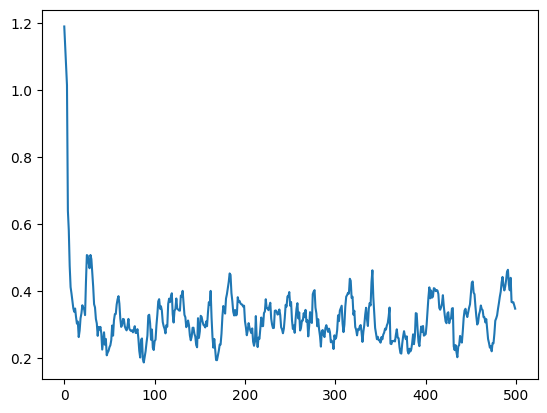

In [9]:
plt.plot(np.sqrt(mse_ts))

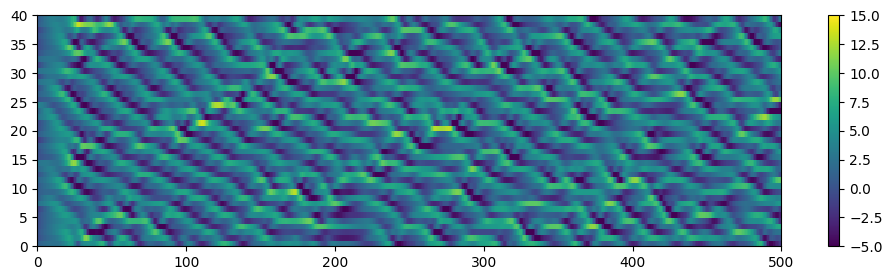

In [10]:
# Hovmoeller diagram of the truth
plt.figure(figsize=(12,3))
c = plt.pcolor(truth_state.T, vmin=-5, vmax=15)
plt.colorbar(c)

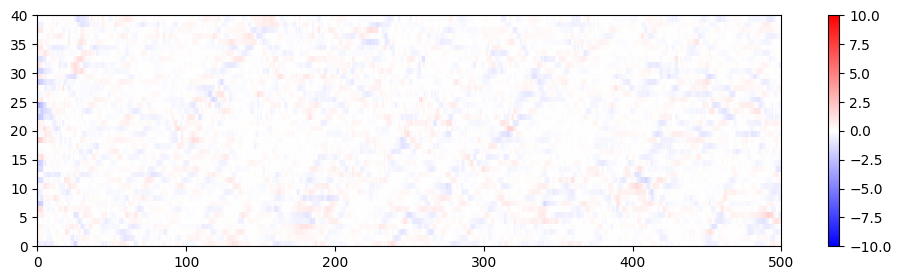

In [11]:
# Hovmoeller diagram of the posterior error against the truth
plt.figure(figsize=(12,3))
c = plt.pcolor((np.mean(post_state, axis=1) - truth_state).T, vmin=-10, vmax=10, cmap='bwr')
plt.colorbar(c)

## Experiment with different parameters

Reproducing Fig. 5.7 of [Boquet's lecture notes](https://cerea.enpc.fr/HomePages/bocquet/teaching/assim-mb-en-0.52.pdf)

H = I, R = I, 

first a range of nens and hroi are tested

note: we will run shorter experiments nt = 500 with 100-cycle burn-in period (instead of 1e5 cycles with a burn-in period of 5e3 cycles in the lecture notes)

In [25]:
nens_try = [5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]
hroi_try = [0.5, 1, 2, 3, 5, 8, 12, 18, 25, 40, 60, 80, np.inf]
burnin = 100

In [ ]:
rmse = np.full((len(nens_try), len(hroi_try)), np.nan)

for i,nens in enumerate(nens_try):
    for j,hroi in enumerate(hroi_try):
        config = Config(config_file="lorenz96/config.yml", quiet=True)
        config.assimilator_def['type'] = 'ETKF'
        config.nens = nens
        config.obs_def[obs_rec_id]['hroi'] = hroi
        scheme = get_scheme(config)
        scheme()
        truth_state = get_truth(scheme)
        post_state = get_model_state(scheme, 'post')
        mse_ts = np.mean((np.mean(post_state, axis=1) - truth_state)**2, axis=1)
        rmse[i,j] = np.sqrt(np.mean(mse_ts[burnin:]))
        print(f'finished case: nens={nens}, hroi={hroi}, rmse={rmse[i,j]}')


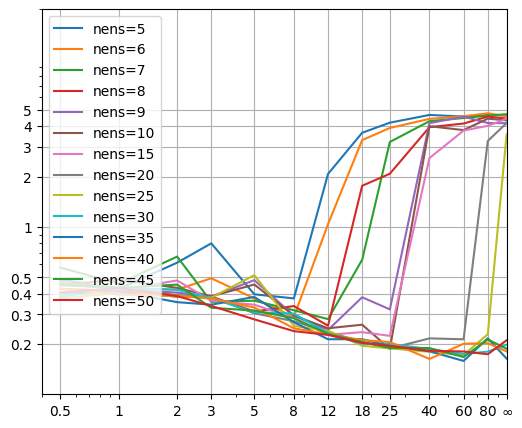

In [29]:
fig, ax = plt.subplots(1,1,figsize=(6,5))
hroi_try[-1] = 100
hroi_try_out = [str(h) for h in hroi_try]
hroi_try_out[-1] = r'$\infty$'

for i,nens in enumerate(nens_try):
    ax.loglog(hroi_try, rmse[i,:], label=f'nens={nens}')

ax.set_xlim([0.4, 100])
ax.set_xticks(hroi_try)
ax.set_xticklabels(hroi_try_out)
ax.set_ylim([0.1, 20])
ylevs = [0.2, 0.3, 0.4, 0.5, 1, 2, 3, 4, 5]
ax.set_yticks(ylevs)
ax.set_yticklabels(ylevs)
ax.grid()
ax.legend(loc='upper left')

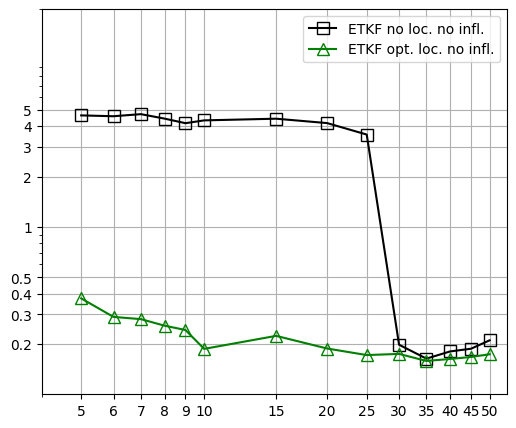

In [30]:
fig, ax = plt.subplots(1,1,figsize=(6,5))
ax.loglog(nens_try, rmse[:,-1], 'ks-', markerfacecolor='none', markersize=8, label='ETKF no loc. no infl.')
ax.loglog(nens_try, np.min(rmse, axis=1), 'g^-',  markerfacecolor='none', markersize=8, label='ETKF opt. loc. no infl.')
ax.set_xlim([4, 55])
ax.set_xticks(nens_try)
ax.set_xticklabels(nens_try)
ax.set_ylim([0.1, 20])
ylevs = [0.2, 0.3, 0.4, 0.5, 1, 2, 3, 4, 5]
ax.set_yticks(ylevs)
ax.set_yticklabels(ylevs)
ax.grid()
ax.legend(loc='upper right')